In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

In [52]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [182]:
def DistributionPlot(RedFunction, BlueFunction, Redname, Bluename,Title):
    width=8
    height=8
    plt.figure(figsize=(width,height))
    ax1=sns.kdeplot(RedFunction,color='r',label=Redname)
    ax2=sns.kdeplot(BlueFunction,color='b',label=Bluename,ax=ax1)
    plt.title(Title)
    plt.xlabel("Price(in dollars)")
    plt.ylabel("Proportion of cars")
    plt.legend()
    plt.show()
    plt.close()

In [178]:
def PloyPlot(xtrain,xtest,ytrain,ytest,lr,pr):
    width=8
    height=8
    plt.figure(figsize=(width,height))
    xmax=max([xtrain.values.max(),xtest.values.max()])
    xmin=min([xtrain.values.min(),xtest.values.min()])
    x=np.arange(xmin,xmax,0.1)
    plt.plot(xtrain,ytrain,'ro',label='Training Data')
    plt.plot(xtest,ytest,'go',label='Testing Data')
    plt.plot(x,lr.predict(pr.fit_transform(x.reshape(-1,1))),label='Predicted Function')    
    plt.ylabel('Price')
    plt.ylim([-5000,50000])
    plt.legend()
    plt.show()
    plt.close()

In [3]:
data=pd.read_csv("automobileEDA.csv")
data.head(10)

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1
5,2,122,audi,std,two,sedan,fwd,front,99.8,0.851994,...,8.5,110.0,5500.0,19,25,15250.0,12.368421,Medium,0,1
6,1,158,audi,std,four,sedan,fwd,front,105.8,0.925997,...,8.5,110.0,5500.0,19,25,17710.0,12.368421,Medium,0,1
7,1,122,audi,std,four,wagon,fwd,front,105.8,0.925997,...,8.5,110.0,5500.0,19,25,18920.0,12.368421,Medium,0,1
8,1,158,audi,turbo,four,sedan,fwd,front,105.8,0.925997,...,8.3,140.0,5500.0,17,20,23875.0,13.823529,Medium,0,1
9,2,192,bmw,std,two,sedan,rwd,front,101.2,0.849592,...,8.8,101.0,5800.0,23,29,16430.0,10.217391,Low,0,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    int64  
 2   make               201 non-null    object 
 3   aspiration         201 non-null    object 
 4   num-of-doors       201 non-null    object 
 5   body-style         201 non-null    object 
 6   drive-wheels       201 non-null    object 
 7   engine-location    201 non-null    object 
 8   wheel-base         201 non-null    float64
 9   length             201 non-null    float64
 10  width              201 non-null    float64
 11  height             201 non-null    float64
 12  curb-weight        201 non-null    int64  
 13  engine-type        201 non-null    object 
 14  num-of-cylinders   201 non-null    object 
 15  engine-size        201 non-null    int64  
 16  fuel-system        201 non

In [5]:
data['stroke']=data['stroke'].replace(np.nan,data['stroke'].mean())

In [6]:
data['stroke'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 201 entries, 0 to 200
Series name: stroke
Non-Null Count  Dtype  
--------------  -----  
201 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


In [7]:
df1=data

In [8]:
df1.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [9]:
df1=df1._get_numeric_data()

In [10]:
df1.columns

Index(['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'city-L/100km', 'diesel', 'gas'],
      dtype='object')

In [11]:
y_data=df1['price']

In [12]:
x_data=df1.drop('price',axis=1)

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x_data,y_data,test_size=0.15,random_state=42)
print("The samples in training dataset is:",x_train.shape[0])
print("The samples in testing dataset is:",x_test.shape[0])

The samples in training dataset is: 170
The samples in testing dataset is: 31


In [14]:
lin_model1=LinearRegression()
lin_model1.fit(x_train[['horsepower']],y_train)

LinearRegression()

In [15]:
y_train_pred=lin_model1.predict(x_train[['horsepower']])
y_test_pred=lin_model1.predict(x_test[['horsepower']])
print(" prediction for training data:",y_train_pred)
print(" prediction for testing data:",y_test_pred)

 prediction for training data: [ 7640.692051   17412.37893769  7340.02476218  6438.02289572
 11699.70045009  8091.69298423  9444.69578393 14556.03969389
 12451.36867214 18915.7153818  17262.04529328 10046.03036157
  7340.02476218 18615.04809298 14255.37240507  5836.68831808
  7640.692051   11248.69951686  7490.35840659 18464.71444857
 21321.05369237 13654.03782743 12790.54507185  7340.02476218
  7340.02476218  9444.69578393 19968.05089267 10948.03222804
 11699.70045009  8091.69298423 11699.70045009  6137.3556069
 15307.70791594  8542.69391747  7340.02476218  8843.36120629
 14255.37240507  7490.35840659  8091.69298423  7340.02476218
 12790.54507185 13954.70511625 12150.70138332  7340.02476218
 11399.03316127 12451.36867214 11248.69951686 19968.05089267
 11399.03316127 20268.7181815  14556.03969389 36504.75177784
 21471.38733678 14255.37240507 14556.03969389 13954.70511625
 10046.03036157 14255.37240507  9745.36307275 12451.36867214
 13804.37147184 21170.72004796  8542.69391747 15307.707

In [16]:
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)
print(" Training MSE:",train_mse)
print(" Testing MSE:",test_mse)

 Training MSE: 15970355.294349
 Testing MSE: 59048252.02324724


In [17]:
train_r2score=r2_score(y_train,y_train_pred)
test_r2score=r2_score(y_test,y_test_pred)
print(" R2 square train:",train_r2score)
print(" R2 square test:",test_r2score)

 R2 square train: 0.6376380177917466
 R2 square test: 0.582249754361498


In [18]:
from sklearn.model_selection import cross_val_score

In [19]:
rsquare_score=cross_val_score(lin_model1,x_data[['horsepower']],y_data,cv=4,scoring='r2')
rsquare_score

array([0.7746232 , 0.51716687, 0.74785353, 0.04839605])

In [20]:
print(" The mean of rsquare value from cross validation score:",np.mean(rsquare_score))

 The mean of rsquare value from cross validation score: 0.522009915042119


In [21]:
meansquaredvalue=cross_val_score(lin_model1,x_data[['horsepower']],y_data,cv=4,scoring='neg_mean_squared_error')
print(" The mean squared error from the cross validation score:", -1*(np.mean(meansquaredvalue)))

 The mean squared error from the cross validation score: 23525298.54198599


In [44]:
lin_model2=LinearRegression()
lin_model2.fit(x_train[['horsepower','curb-weight','engine-size','highway-mpg']],y_train)

LinearRegression()

In [46]:
y_train_pred2=lin_model2.predict(x_train[['horsepower','curb-weight','engine-size','highway-mpg']])
y_train_pred2[0:5]

array([ 5531.78093721, 10371.36625021,  6414.93156958,  7706.16568291,
       14302.97675043])

In [48]:
y_test_pred2=lin_model2.predict(x_test[['horsepower','curb-weight','engine-size','highway-mpg']])
y_test_pred2[0:5]

array([ 6897.02648092, 25284.39657642,  5913.5435124 ,  7697.94493387,
       13103.25889482])

In [50]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

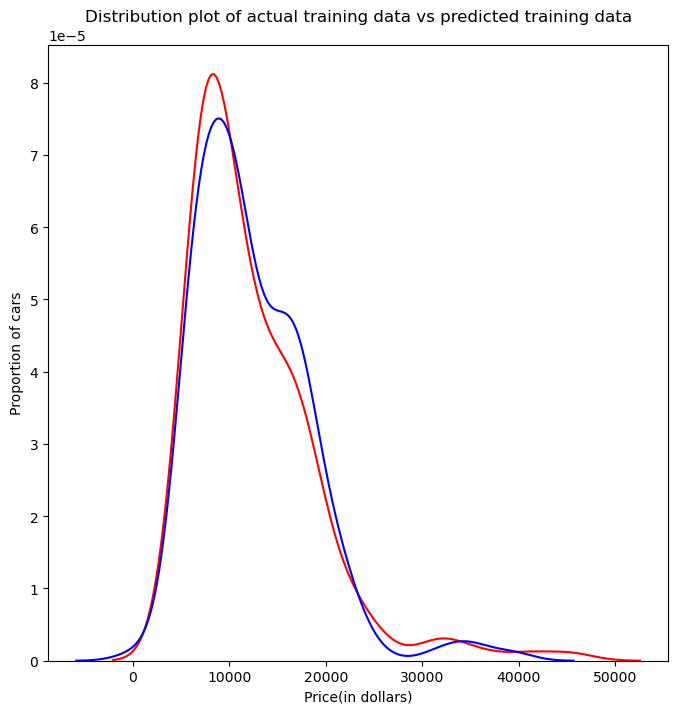

In [76]:
Title="Distribution plot of actual training data vs predicted training data"
DistributionPlot(y_train,y_train_pred2,"Actual values(test)","Predicted values(test)",Title)

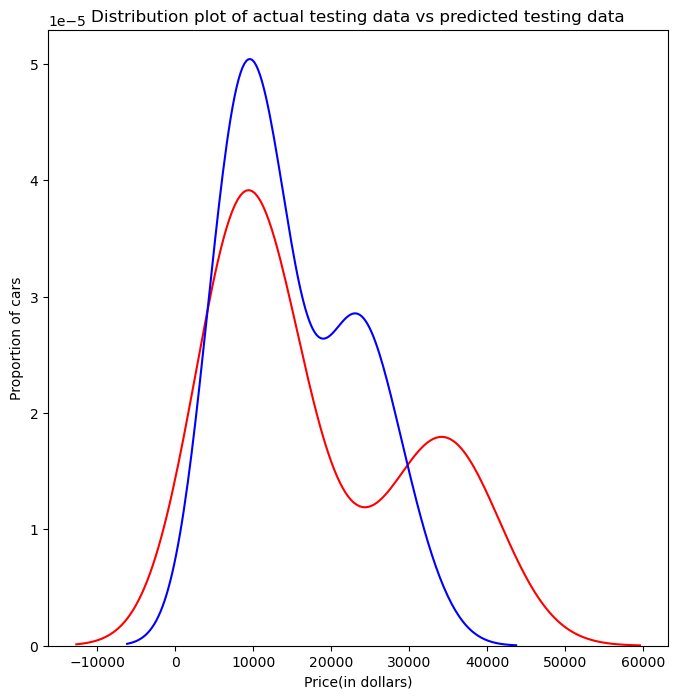

In [78]:
Title="Distribution plot of actual testing data vs predicted testing data"
DistributionPlot(y_test,y_test_pred2,"Actual values(test)","Predicted values(test)",Title)

In [80]:
x_train,x_test,y_train,y_test=train_test_split(x_data,y_data,test_size=0.45,random_state=0)

In [82]:
# using the feature=horsepower and degree 5

In [84]:
polyfeat=PolynomialFeatures(degree=5,include_bias=False)
x_train_pr=polyfeat.fit_transform(x_train[['horsepower']])
x_test_pr=polyfeat.fit_transform(x_test[['horsepower']])

In [86]:
poly=LinearRegression()
poly.fit(x_train_pr,y_train)

LinearRegression()

In [88]:
y_train_pr=poly.predict(x_train_pr)
y_train_pr[0:5]

array([13157.92035118, 21890.66396807,  6409.63053402, 21231.60220944,
        7905.42418877])

In [90]:
y_test_pr=poly.predict(x_test_pr)
y_test_pr[0:5]

array([ 6728.70364441,  7308.02900289, 12213.79115979, 18893.18938581,
       19995.88636635])

In [94]:
print("Predicted values:",y_test_pr[0:5])
print("Actual values(splitted testing data):",y_test[0:5].values)

Predicted values: [ 6728.70364441  7308.02900289 12213.79115979 18893.18938581
 19995.88636635]
Actual values(splitted testing data): [ 6295. 10698. 13860. 13499. 15750.]


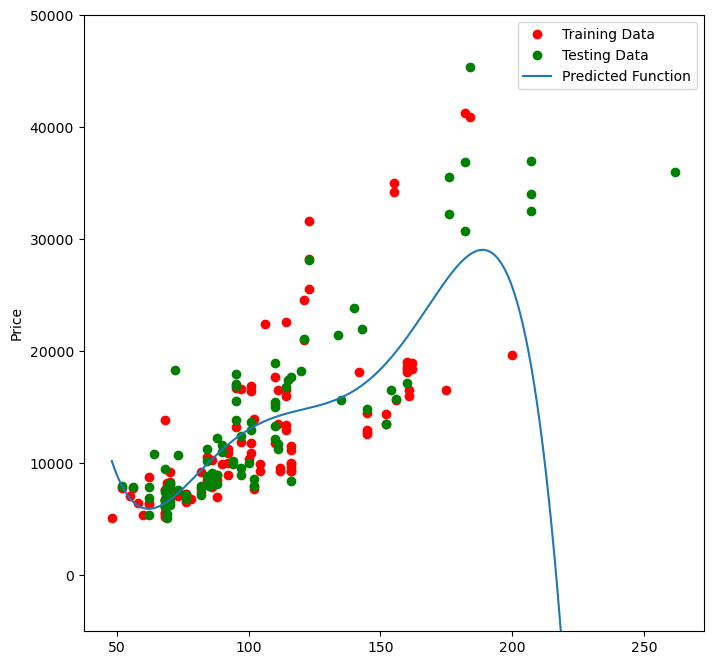

In [146]:
PloyPlot(x_train[['horsepower']],x_test[['horsepower']],y_train,y_test,poly,polyfeat)

In [148]:
# calculating the r2 square value for the tranformed training data and testing data


In [152]:
print(" The r squared value for the transformed training data:",poly.score(x_train_pr,y_train))

 The r squared value for the transformed training data: 0.5567716902648971


In [154]:
print(" The r squared value for the tranformed testing data:",poly.score(x_test_pr,y_test))

 The r squared value for the tranformed testing data: -29.871453716983073


In [156]:
# Degree chosen was 5, lets see how r2 score/value changes as the degree progresses

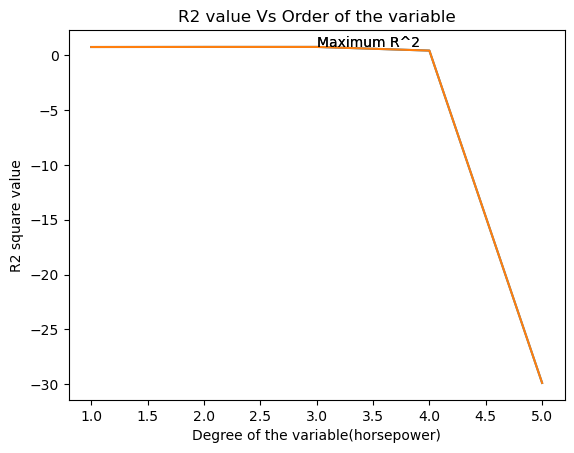

In [162]:
rsqau_test=[]
order=[1,2,3,4,5]
for n in order:
    polyfeat=PolynomialFeatures(n)
    x_train_transform=polyfeat.fit_transform(x_train[['horsepower']])
    x_test_transform=polyfeat.fit_transform(x_test[['horsepower']])
    poly.fit(x_train_transform,y_train)
    rsqau_test.append(poly.score(x_test_transform,y_test))

                      
plt.plot(order,rsqau_test)
plt.xlabel('Degree of the variable(horsepower)')
plt.ylabel('R2 square value')
plt.title('R2 value Vs Order of the variable')
plt.text(3, 0.75, 'Maximum R^2 ') 
plt.show()
plt.close()
    

In [166]:
# Q1. 
pr1=PolynomialFeatures(degree=2)
x_train_pr1=pr1.fit_transform(x_train[['horsepower','curb-weight','engine-size','highway-mpg']])
x_test_pr1=pr1.fit_transform(x_test[['horsepower','curb-weight','engine-size','highway-mpg']])

In [168]:
x_train_pr1.shape

(110, 15)

In [170]:
poly1=LinearRegression()
poly1.fit(x_train_pr1,y_train)

LinearRegression()

In [172]:
y_test_pr1=poly1.predict(x_test_pr1)
y_test_pr1[0:5]

array([ 6303.02917837, 10402.87148099, 20516.37185608, 19273.87340838,
       20555.51694567])

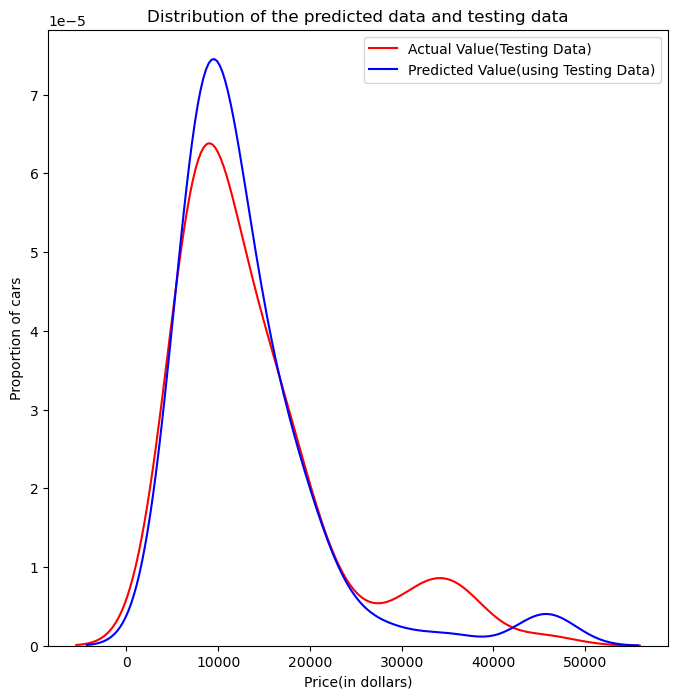

In [180]:
Title="Distribution of the predicted data and testing data"
DistributionPlot(y_test,y_test_pr1,"Actual Value(Testing Data)","Predicted Value(using Testing Data)",Title)

In [200]:
pr2=PolynomialFeatures(degree=2)
x_train_pr2=pr2.fit_transform(x_train[['horsepower','curb-weight','engine-size','highway-mpg','normalized-losses','symboling']])
x_test_pr2=pr2.fit_transform(x_test[['horsepower','curb-weight','engine-size','highway-mpg','normalized-losses','symboling']])

In [202]:
from sklearn.linear_model import Ridge

In [210]:
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train_pr2,y_train)

C:\Users\Techjockey\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.02972e-16): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Ridge(alpha=0.1)

In [216]:
y_pred_train=RidgeModel.predict(x_train_pr2)
y_pred_test=RidgeModel.predict(x_test_pr2)
print(" The r2 score value using ridgemodel(training) is:",RidgeModel.score(x_train_pr2,y_train))
print(" The r2 score value using ridgemodel(testing) is:",RidgeModel.score(x_test_pr2,y_test))

 The r2 score value using ridgemodel(training) is: 0.8710450895852535
 The r2 score value using ridgemodel(testing) is: 0.526727386750402


In [218]:
print(" The MSE using ridgemodel(training) is:",mean_squared_error(y_train,y_pred_train))
print(" The r2 score value using ridgemodel(testing) is:",mean_squared_error(y_test,y_pred_test))

 The MSE using ridgemodel(training) is: 6746451.122540831
 The r2 score value using ridgemodel(testing) is: 35365465.60137966


In [ ]:
# selecting the value of alpha such that the MSE is minimized

In [222]:
rsquare_test=[]
rsquare_train=[]
numbers=10*(np.arange(0,1000))
for n in numbers:
    RidgeModel=Ridge(alpha=n)
    RidgeModel.fit(x_train_pr2,y_train)
    rsquare_test.append(RidgeModel.score(x_test_pr2,y_test))
    rsquare_train.append(RidgeModel.score(x_train_pr2,y_train))


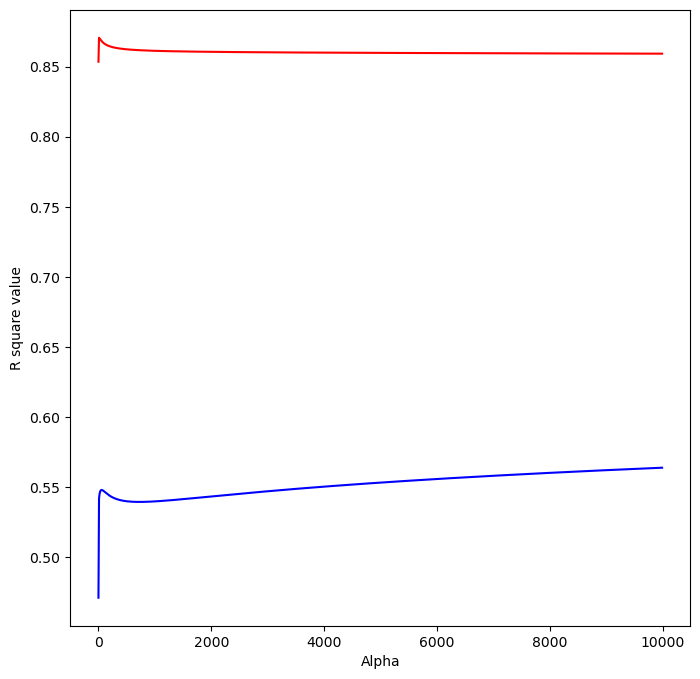

In [224]:
width=8
height=8
plt.figure(figsize=(width,height))
plt.plot(numbers,rsquare_test,color='b',label='Testing R2 value')
plt.plot(numbers,rsquare_train,color='r',label='Training R2 value')
plt.xlabel('Alpha')
plt.ylabel('R square value')
plt.show()
plt.close()

In [226]:
RidgeModel=Ridge(alpha=10)
RidgeModel.fit(x_train_pr2,y_train)
print(" The r2 value using trainingdatafor alpha parameter set to 10:",RidgeModel.score(x_train_pr2,y_train))
print(" The r2 value using testingdata for alpha parameter set to 10:",RidgeModel.score(x_test_pr2,y_test))

 The r2 value using trainingdatafor alpha parameter set to 10: 0.8706524475732125
 The r2 value using testingdata for alpha parameter set to 10: 0.5418576440207269


In [230]:
from sklearn.model_selection import GridSearchCV

In [232]:
parameters=[{'alpha':[0.001,0.1,1,10,100,1000,10000,100000]}]
parameters

[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000]}]

In [234]:
RR=Ridge()
RR

Ridge()

In [236]:
grid=GridSearchCV(RR,parameters,cv=4)
grid

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000,
                                    100000]}])

In [238]:
grid.fit(x_data[['horsepower','curb-weight','engine-size','highway-mpg']],y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000,
                                    100000]}])

In [240]:
BestRR=grid.best_estimator_
BestRR

Ridge(alpha=10000)

In [242]:
grid.score(x_test[['horsepower','curb-weight','engine-size','highway-mpg']],y_test)

0.8411649831036152

In [250]:
grid1=GridSearchCV(RR,parameters,cv=4,scoring='neg_mean_squared_error')
grid1.fit(x_data[['horsepower','curb-weight','engine-size','highway-mpg']],y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000,
                                    100000]}],
             scoring='neg_mean_squared_error')

In [252]:
print(" Best alpha:",grid1.best_estimator_)
print(" MSE value:",(-1)*(grid1.best_score_))

 Best alpha: Ridge(alpha=10000)
 MSE value: 15912200.168214824
